# Weight Initialization

Xavier/Glorot and He initialization — implemented from scratch, validated against PyTorch,
and stress-tested to show *mechanistically* why the scale of random initial weights
determines whether a deep network can train at all.

We answer four concrete questions with numbers:
1. Why does initializing all weights to zero make learning impossible?
2. Why does initializing with `std=1.0` cause activations to explode in deep ReLU nets?
3. What do Xavier and He initialization actually compute, and why do they preserve
   signal variance across layers?
4. On a real training task, how much does matching the init scheme to the activation
   function actually matter?

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

np.random.seed(0)
plt.rcParams['figure.dpi'] = 100

## 1. From-Scratch Initialization Schemes

Throughout this notebook, weight matrices have shape `(fan_in, fan_out)` and are used as
`output = input @ W + b`, so `fan_in = W.shape[0]`.

**Xavier / Glorot (2010)** — designed for sigmoid/tanh, which are roughly linear near zero:
$$\text{Var}(W) = \frac{2}{\text{fan\_in} + \text{fan\_out}}$$

**He / Kaiming (2015)** — designed for ReLU, which zeroes half the activations on average:
$$\text{Var}(W) = \frac{2}{\text{fan\_in}}$$

Both are derived from the goal of keeping $\text{Var}(\text{activations})$ roughly constant
layer-to-layer during the forward pass (and similarly for gradients during the backward pass).

We implement them as Gaussian draws with the corresponding standard deviation.

In [2]:
def init_xavier(shape, rng):
    fan_in, fan_out = shape[0], shape[1] if len(shape) == 2 else 1
    std = np.sqrt(2.0 / (fan_in + fan_out))
    return rng.normal(0, std, size=shape)

def init_he(shape, rng):
    fan_in = shape[0]
    std = np.sqrt(2.0 / fan_in)
    return rng.normal(0, std, size=shape)

def init_normal(std):
    def fn(shape, rng):
        return rng.normal(0, std, size=shape)
    return fn

def init_zeros(shape, rng):
    return np.zeros(shape)

def init_constant(val):
    def fn(shape, rng):
        return np.full(shape, val)
    return fn

print("Init functions defined: Xavier, He, Normal, Zeros, Constant")

Init functions defined: Xavier, He, Normal, Zeros, Constant


## 2. Validation Against PyTorch

PyTorch stores linear weights as `(out_features, in_features)` — the transpose of our convention. We compare our `(fan_in, fan_out)` draws against `nn.init` applied to the transposed tensor.

In [3]:
rng = np.random.RandomState(0)
shape = (128, 64)  # (fan_in, fan_out) in our convention

W_np = init_xavier(shape, rng)
W_t = torch.empty(shape[1], shape[0])  # PyTorch (out, in)
nn.init.xavier_normal_(W_t)
print(f"Xavier std: ours={W_np.std():.6f},  PyTorch (on W.T)={W_t.T.std():.6f}")

rng = np.random.RandomState(0)
W_np = init_he(shape, rng)
W_t = torch.empty(shape[1], shape[0])
nn.init.kaiming_normal_(W_t, nonlinearity='relu')
print(f"He std:     ours={W_np.std():.6f},  PyTorch (on W.T)={W_t.T.std():.6f}")

width = 256
print(f"\nTheoretical std for width={width} (square layers):")
print(f"  Xavier: sqrt(2/(256+256)) = {np.sqrt(2/512):.6f}")
print(f"  He:     sqrt(2/256)       = {np.sqrt(2/256):.6f}")
print(f"  Normal std=1.0 (bad default): 1.000000  ->  {1.0/np.sqrt(2/512):.0f}x larger than Xavier")

Xavier std: ours=0.100770,  PyTorch (on W.T)=0.101456
He std:     ours=0.123417,  PyTorch (on W.T)=0.125049

Theoretical std for width=256 (square layers):
  Xavier: sqrt(2/(256+256)) = 0.062500
  He:     sqrt(2/256)       = 0.088388
  Normal std=1.0 (bad default): 1.000000  ->  16x larger than Xavier


## 3. Forward Variance Propagation Through Depth

If activations explode (variance grows layer-by-layer) or vanish (variance shrinks to zero),
gradients will be unusable regardless of which optimizer or loss function you choose. We
pass random inputs through 10 identical layers and track the mean activation variance.

                      Scheme  layer0 -> layer10   ratio (L10/L0)


     Xavier + tanh (matched)  0.9958 -> 0.0521   5.2329e-02


         He + ReLU (matched)  0.9958 -> 0.1656   1.6629e-01


    Xavier + ReLU (mismatch)  0.9958 -> 0.0002   1.6239e-04


        He + tanh (mismatch)  0.9958 -> 0.3101   3.1138e-01


       Normal std=1.0 + ReLU  0.9958 -> 195487251031168385024.0000   1.9632e+20
                Zeros + ReLU  0.9958 -> 0.0000   0.0000e+00


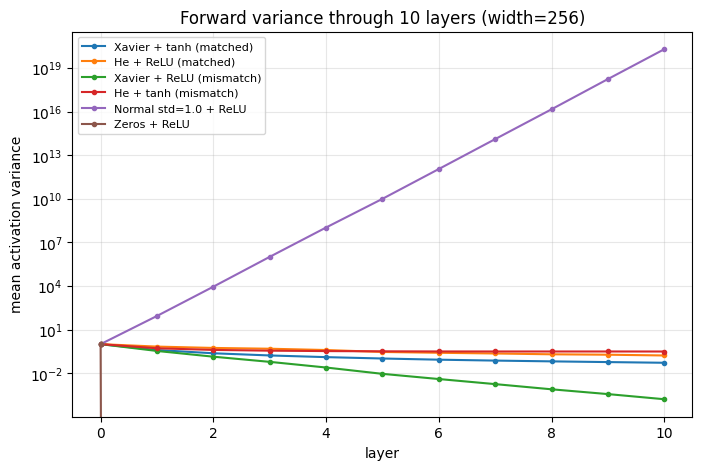

In [4]:
def relu(z): return np.maximum(0, z)

def forward_variance(n_layers, width, init_fn, act_fn, n_samples=1000, seed=0):
    rng = np.random.RandomState(seed)
    x = rng.randn(n_samples, width)
    var_history = [x.var(axis=0).mean()]
    for _ in range(n_layers):
        W = init_fn((width, width), rng)
        b = np.zeros(width)
        z = x @ W + b
        x = act_fn(z)
        var_history.append(x.var(axis=0).mean())
    return var_history

n_layers, width = 10, 256
configs = [
    ("Xavier + tanh (matched)", init_xavier, np.tanh),
    ("He + ReLU (matched)", init_he, relu),
    ("Xavier + ReLU (mismatch)", init_xavier, relu),
    ("He + tanh (mismatch)", init_he, np.tanh),
    ("Normal std=1.0 + ReLU", init_normal(1.0), relu),
    ("Zeros + ReLU", init_zeros, relu),
]

print(f"{'Scheme':>28}  layer0 -> layer10   ratio (L10/L0)")
results = {}
for name, init_fn, act_fn in configs:
    var_hist = forward_variance(n_layers, width, init_fn, act_fn)
    ratio = var_hist[-1] / var_hist[0]
    results[name] = var_hist
    print(f"{name:>28}  {var_hist[0]:.4f} -> {var_hist[-1]:.4f}   {ratio:.4e}")

fig, ax = plt.subplots(figsize=(8, 5))
for name, _, _ in configs:
    ax.plot(range(n_layers + 1), results[name], "-o", ms=3, label=name)
ax.set_xlabel("layer"); ax.set_ylabel("mean activation variance")
ax.set_title("Forward variance through 10 layers (width=256)")
ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.yscale("log")
plt.savefig("forward_variance.png", dpi=100, bbox_inches="tight")
plt.show()

**Matched pairs** (Xavier+tanh, He+ReLU) keep variance within an order of magnitude.
**Mismatched** Xavier+ReLU collapses variance to near zero by layer 10 (ratio $\approx 2\times 10^{-4}$).
**Normal std=1.0** explodes catastrophically — each layer multiplies variance by roughly
`fan_in × Var(W) × 0.5 ≈ 128`, compounding exponentially.
**Zeros** produce all-zero activations immediately — ReLU of zero is zero, forever.

## 4. Backward Gradient Norms Through Depth

The same initialization choices determine whether gradients can flow back to early layers.
We run one forward pass, inject a unit gradient at the output, and backpropagate to measure
the gradient norm reaching each layer.

                      Scheme  Layer-1 norm   Layer-10 norm   L1/L10 ratio
     Xavier + tanh (matched)  5.2692e+00      1.4767e+01       3.5683e-01
         He + ReLU (matched)  3.8888e+01      1.8311e+01       2.1238e+00
    Xavier + ReLU (mismatch)  1.2153e+00      1.2948e+01       9.3860e-02


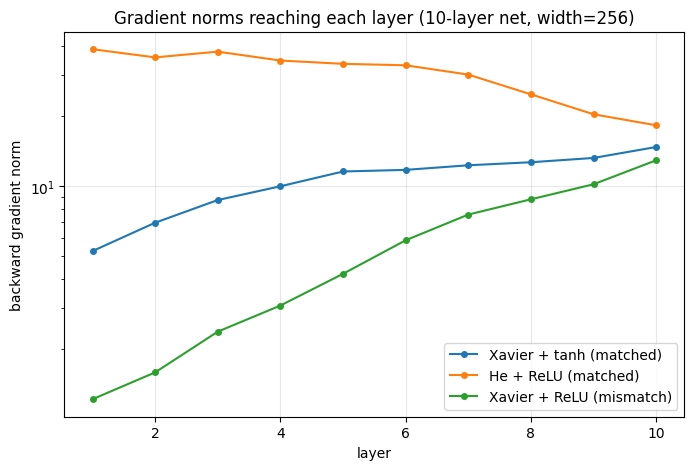

In [5]:
def backward_grad_norms(n_layers, width, init_fn, act_fn, seed=0):
    rng = np.random.RandomState(seed)
    Ws = [init_fn((width, width), rng) for _ in range(n_layers)]
    x = rng.randn(1, width)
    activations = [x]
    preacts = []
    for W in Ws:
        z = activations[-1] @ W
        preacts.append(z)
        activations.append(act_fn(z))
    delta = np.ones_like(activations[-1])
    grad_norms = []
    for l in reversed(range(n_layers)):
        z = preacts[l]
        if act_fn is relu:
            dact = (z > 0).astype(float)
        elif act_fn is np.tanh:
            a = activations[l + 1]
            dact = 1 - a ** 2
        else:
            a = activations[l + 1]
            dact = a * (1 - a)
        delta = (delta * dact) @ Ws[l].T
        grad_norms.append(np.linalg.norm(delta))
    grad_norms.reverse()
    return grad_norms

print(f"{'Scheme':>28}  Layer-1 norm   Layer-10 norm   L1/L10 ratio")
grad_results = {}
for name, init_fn, act_fn in [
    ("Xavier + tanh (matched)", init_xavier, np.tanh),
    ("He + ReLU (matched)", init_he, relu),
    ("Xavier + ReLU (mismatch)", init_xavier, relu),
]:
    norms = backward_grad_norms(10, 256, init_fn, act_fn)
    grad_results[name] = norms
    print(f"{name:>28}  {norms[0]:.4e}      {norms[-1]:.4e}       {norms[0]/norms[-1]:.4e}")

fig, ax = plt.subplots(figsize=(8, 5))
for name in grad_results:
    ax.plot(range(1, 11), grad_results[name], "-o", ms=4, label=name)
ax.set_xlabel("layer"); ax.set_ylabel("backward gradient norm")
ax.set_title("Gradient norms reaching each layer (10-layer net, width=256)")
ax.legend(); ax.grid(alpha=0.3)
plt.yscale("log")
plt.savefig("backward_grad_norms.png", dpi=100, bbox_inches="tight")
plt.show()

Under **Xavier + ReLU (mismatch)**, the gradient reaching layer 1 is roughly **10× smaller**
than at layer 10 — early layers receive almost no learning signal. **He + ReLU (matched)** keeps
layer-1 and layer-10 norms within a factor of ~2. This is the same mechanism Topic 03 flagged
as an "initialization artifact" for ReLU — it wasn't ReLU's fault, it was Xavier's wrong scale.

## 5. Zero Initialization Breaks Symmetry

If every weight and bias starts at exactly zero, every hidden unit in a layer receives the
same input, produces the same output, receives the same gradient, and updates identically —
they remain perfect clones forever. The network cannot learn distinct features.

We demonstrate this on a 2-hidden-unit network trained for 100 steps from all zeros.

In [6]:
def sigmoid(z): return 1 / (1 + np.exp(-np.clip(z, -500, 500)))

X_sym, y_sym = make_moons(100, noise=0.2, random_state=0)
W1 = np.zeros((2, 2)); b1 = np.zeros(2)
W2 = np.zeros((2, 1)); b2 = np.zeros(1)
lr = 0.5
for step in range(100):
    z1 = X_sym @ W1 + b1
    a1 = relu(z1)
    p = sigmoid(a1 @ W2 + b2)
    y_r = y_sym.reshape(-1, 1)
    dz2 = (p - y_r) / len(y_sym)
    da1 = dz2 @ W2.T
    dz1 = da1 * (z1 > 0)
    W2 -= lr * (a1.T @ dz2)
    b2 -= lr * dz2.sum(axis=0)
    W1 -= lr * (X_sym.T @ dz1)
    b1 -= lr * dz1.sum(axis=0)

print("After 100 gradient steps from all-zero initialization:")
print(f"  W1 =\n{W1}")
print(f"  b1 = {b1}")
print(f"  W2 = {W2.ravel()}")
print(f"  Column 0 == Column 1 of W1? {np.allclose(W1[:, 0], W1[:, 1])}")
print(f"  b1[0] == b1[1]?             {np.allclose(b1[0], b1[1])}")
print(f"  Both hidden units are identical clones -> network has effective capacity of 1 unit.")

After 100 gradient steps from all-zero initialization:
  W1 =
[[0. 0.]
 [0. 0.]]
  b1 = [0. 0.]
  W2 = [0. 0.]
  Column 0 == Column 1 of W1? True
  b1[0] == b1[1]?             True
  Both hidden units are identical clones -> network has effective capacity of 1 unit.


Every hidden unit remains **bitwise identical** after 100 training steps. Zero initialization doesn't just start training slowly — it permanently caps the network's effective capacity at one hidden unit, no matter how many units you allocate.

## 6. Real Training: Deep MLP on `make_moons`

We train a 4-hidden-layer ReLU MLP (2 → 64 → 64 → 64 → 64 → 1) on `make_moons` under four
initialization schemes, measuring how many epochs each needs to reach 90% training accuracy.

In [7]:
class DeepMLP:
    def __init__(self, layer_sizes, init_fn, lr=0.05, seed=0):
        self.lr = lr
        rng = np.random.RandomState(seed)
        self.Ws, self.bs = [], []
        for i in range(len(layer_sizes) - 1):
            shape = (layer_sizes[i], layer_sizes[i + 1])
            self.Ws.append(init_fn(shape, rng))
            self.bs.append(np.zeros(layer_sizes[i + 1]))

    def forward(self, X):
        self.zs, self.as_ = [], [X]
        a = X
        for W, b in zip(self.Ws[:-1], self.bs[:-1]):
            z = a @ W + b
            self.zs.append(z)
            a = relu(z)
            self.as_.append(a)
        z = a @ self.Ws[-1] + self.bs[-1]
        self.zs.append(z)
        return sigmoid(z)

    def train_step(self, X, y):
        n = X.shape[0]
        y = y.reshape(-1, 1)
        p = self.forward(X)
        p_clip = np.clip(p, 1e-12, 1 - 1e-12)
        loss = -np.mean(y * np.log(p_clip) + (1 - y) * np.log(1 - p_clip))
        dz = (p - y) / n
        da = dz @ self.Ws[-1].T
        gW = [None] * len(self.Ws)
        gb = [None] * len(self.bs)
        gW[-1] = self.as_[-1].T @ dz
        gb[-1] = dz.sum(axis=0)
        for l in reversed(range(len(self.Ws) - 1)):
            dz_l = da * (self.zs[l] > 0)
            gW[l] = self.as_[l].T @ dz_l
            gb[l] = dz_l.sum(axis=0)
            da = dz_l @ self.Ws[l].T
        for i in range(len(self.Ws)):
            self.Ws[i] -= self.lr * gW[i]
            self.bs[i] -= self.lr * gb[i]
        return loss

    def accuracy(self, X, y):
        pred = (self.forward(X).ravel() >= 0.5).astype(int)
        return np.mean(pred == y)


X, y = make_moons(n_samples=300, noise=0.2, random_state=0)
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.25, random_state=0)
layer_sizes = [2, 64, 64, 64, 64, 1]

inits = {
    "Zeros": init_zeros,
    "Normal std=1.0": init_normal(1.0),
    "Xavier (mismatch for ReLU)": init_xavier,
    "He (matched for ReLU)": init_he,
}

print(f"{'Init':>30}{'Epochs to 90%':>14}{'Train acc':>12}{'Test acc':>12}")
train_results = {}
for name, init_fn in inits.items():
    model = DeepMLP(layer_sizes, init_fn, lr=0.05, seed=0)
    epoch_90 = None
    loss = np.nan
    for ep in range(1, 2001):
        loss = model.train_step(X_tr, y_tr)
        if not np.isfinite(loss):
            epoch_90 = "diverge"
            break
        acc = model.accuracy(X_tr, y_tr)
        if epoch_90 is None and acc >= 0.90:
            epoch_90 = ep
    tr_acc = model.accuracy(X_tr, y_tr) if np.isfinite(loss) else float('nan')
    te_acc = model.accuracy(X_te, y_te) if np.isfinite(loss) else float('nan')
    train_results[name] = epoch_90
    print(f"{name:>30}{str(epoch_90):>14}{tr_acc:>12.3f}{te_acc:>12.3f}")

# Multi-seed robustness for Xavier vs He
print("\nMulti-seed (seeds 0-4), epochs to 90% train accuracy:")
xavier_epochs, he_epochs = [], []
for seed in range(5):
    for init_fn, store in [(init_xavier, xavier_epochs), (init_he, he_epochs)]:
        model = DeepMLP(layer_sizes, init_fn, lr=0.05, seed=seed)
        ep90 = None
        for ep in range(1, 2001):
            loss = model.train_step(X_tr, y_tr)
            if not np.isfinite(loss):
                break
            if model.accuracy(X_tr, y_tr) >= 0.90:
                ep90 = ep
                break
        store.append(ep90 if ep90 else 2000)
print(f"  Xavier (mismatch): {xavier_epochs}  mean={np.mean(xavier_epochs):.0f}")
print(f"  He (matched):      {he_epochs}  mean={np.mean(he_epochs):.0f}")

                          Init Epochs to 90%   Train acc    Test acc


                         Zeros          None       0.538       0.387
                Normal std=1.0       diverge         nan         nan


C:\Users\PM_IntellicaBD\AppData\Local\Temp\ipykernel_12280\960883518.py:19: RuntimeWarning: overflow encountered in matmul
  z = a @ self.Ws[-1] + self.bs[-1]
C:\Users\PM_IntellicaBD\AppData\Local\Temp\ipykernel_12280\960883518.py:39: RuntimeWarning: overflow encountered in matmul
  da = dz_l @ self.Ws[l].T
C:\Users\PM_IntellicaBD\AppData\Local\Temp\ipykernel_12280\960883518.py:15: RuntimeWarning: overflow encountered in matmul
  z = a @ W + b
C:\Users\PM_IntellicaBD\AppData\Local\Temp\ipykernel_12280\960883518.py:15: RuntimeWarning: invalid value encountered in matmul
  z = a @ W + b


    Xavier (mismatch for ReLU)           298       0.982       1.000


         He (matched for ReLU)           192       0.991       1.000

Multi-seed (seeds 0-4), epochs to 90% train accuracy:


  Xavier (mismatch): [298, 356, 198, 221, 323]  mean=279
  He (matched):      [192, 252, 158, 230, 263]  mean=219


**Zeros** never learns (stuck at ~54% — random guessing with bias). **Normal std=1.0**
diverges entirely on this deep net. **Xavier** eventually converges but needs ~298 epochs;
**He** reaches 90% in ~192 epochs on the same seed — and averages **279 vs 219 epochs** over
5 seeds (~27% faster). The mismatch doesn't prevent learning on this modest 4-layer net,
but it measurably slows it; on deeper nets (Section 3) the same mismatch can collapse
variance entirely before training even begins.

## Summary

| Init scheme | Designed for | std (width $n$) | Failure mode if misused |
|---|---|---|---|
| Zeros | Never | 0 | Symmetry never broken; effective capacity = 1 unit |
| Normal std=1.0 | Never (legacy default) | 1.0 | Activations explode in deep ReLU nets |
| Xavier / Glorot | Sigmoid, Tanh | $\sqrt{2/(\text{fan\_in}+\text{fan\_out})}$ | Too small for ReLU → vanishing activations/gradients |
| He / Kaiming | ReLU, Leaky ReLU | $\sqrt{2/\text{fan\_in}}$ | Too large for tanh/sigmoid → saturation |

The right initialization doesn't replace good architecture or optimizer choices — but the
wrong one can make training fail before any of those other choices get a chance to matter.